In [1]:
using IonSim
using QuantumOptics
using PyPlot

In [2]:
function plot_wigner(final_state)
    rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end


plot_wigner (generic function with 1 method)

In [3]:
function SDF_apply_with_alpha(angle = 0, time = 50.0, cat_state = false, initial_state = nothing)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        println("Preparing cat state superposition...")
        red_angle = -angle
        blue_angle = angle
    end
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

   k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    println(mode)

    ψ_ion = normalize(ion["g"] -  ion["e"])

    
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        println("Using provided initial state...")
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]

    # ---------------------------------------------------------
# 1. Fundamental Physics Constants
# ---------------------------------------------------------
 hbar = 1.0545718e-34       # Reduced Planck constant (J*s)
 amu = 1.66053906e-27       # Atomic mass unit (kg)
 m_Ca40 = 39.96259 * amu    # Mass of Calcium-40 ion (kg)
 c = 2.99792458e8           # Speed of light (m/s)

# ---------------------------------------------------------
# 2. Your Simulated Experiment Parameters
# ---------------------------------------------------------     
wavelength = transition_λ             # Quadrupole transition wavelength (m)
tspan_end = time * 1e-6              # Total laser interaction time (s)
# ---------------------------------------------------------
# 3. Step-by-Step Calculation
# ---------------------------------------------------------

println("--- VERIFYING DISPLACEMENT PARAMETERS ---")

# Step A: Zero-Point Fluctuation (z_zpf)
# z_zpf = sqrt( ħ / (2 * m * ω_trap) )
omega_trap = 2 * π * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")

# Step B: Wavevector Z-Projection (k_z)
# Your vector: k_vec = (x̂ + ẑ) / √2 
# Therefore, projection onto Z is 1/√2
k_total = 2 * π / wavelength
k_z = k_total / sqrt(2)
println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")

# Step C: Lamb-Dicke Parameter (η)
# η = k_z * z_zpf
eta = k_z * z_zpf
println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))

# Step D: Effective Rabi Frequency (Ω_eff)
# The geometric coupling factor for a Δm=0 quadrupole transition using your 
# specific k_vec and ϵ_vec vectors results in a scaling reduction of 1/4.
# geometric_factor = 1.0 / 4.0
geometric_factor = 1.0 / ( sqrt(3)) 

# STRETCHED STATE: The CG coefficient is exactly 1.0! 
cg_factor = 1.0 # The Clebsch-Gordan factor for Δm=0 in Ca40

# The true effective Rabi frequency acting on the ion's orbitals
Omega_eff = laser_intensity * geometric_factor * cg_factor
println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

# Step E: Displacement Magnitude (|α|)
# |α| = 1/2 * η * Ω_eff * t 
alpha_mag = 0.5 * eta * Omega_eff * tspan_end 

println("-----------------------------------------")
println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3))
println("-----------------------------------------")
return final_state
end


SDF_apply_with_alpha (generic function with 5 methods)

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
Simulating bichromatic displacement...
--- VERIFYING DISPLACEMENT PARAMETERS ---
Zero-Point Fluctuation (z_zpf) : 8.1584 nm
Z-Projected Wavevector (k_z)   : 6.09326094e6 m⁻¹
Lamb-Dicke Parameter (η)       : 0.0497
Effective Rabi Freq (Ω_eff)    : 577350.2691896259 rad/s
-----------------------------------------
FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : 0.718
-----------------------------------------
Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.5477213734090359 - 0.00023487500897333im
  -0.5476007566119574 + 0.00023485529864395im
  0.00016780822031409 + 0.39163878669608054im
  -0.0001678462875938 - 0.39163884881932054im
 -0.19772909785026843 + 8.469671539906e-5im
  0.19785594232118597 - 8.47091739709e-5im
   -3.490070021561e-5 - 0.0814617953903451im
     3.48303344135e-5 + 0.08146158848660194im
  0.02899792282099058 - 1.241159389896e-5im
 -0.02904140963773813 + 1.241755491722e-5im
     3.96490666221e-

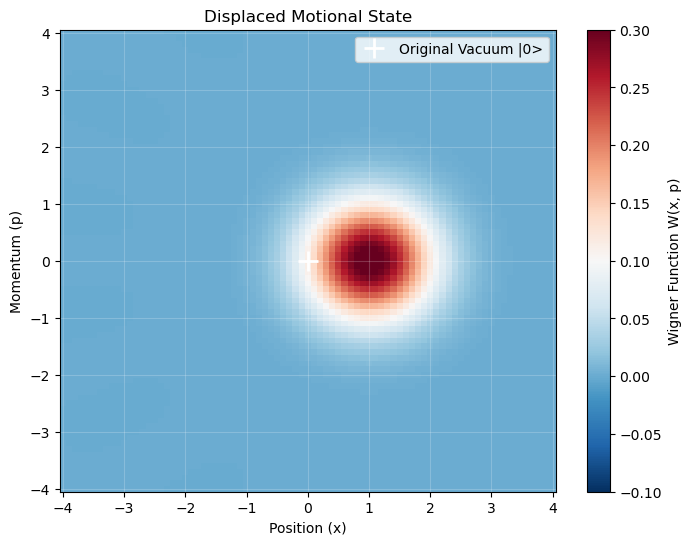

In [4]:
final_state = SDF_apply_with_alpha(0, 50.0, false)

println(final_state)
plot_wigner(final_state)



In [5]:
trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)
    mode = zmodes(trap)[1]
    println(mode)
    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)


Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
  0.7071067811865475 + 0.0im
 -0.7071067811865475 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                     ⋮
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im

In [21]:
function SDF_apply_with_alpha(angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        println("Preparing cat state superposition...")
        red_angle = -angle
        blue_angle = angle
    end
    
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e4 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

    # ---------------------------------------------------------
    # NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    c = 2.99792458e8           

    # 1. Calculate Lamb-Dicke Parameter (η) dynamically
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    # 2. Hijack IonSim's internal matrix element calculator
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Feed the dummy laser into the exact internal physics engine
    # (Note: Unexported internal functions need the module prefix 'IonSim.')
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    # 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    # ---------------------------------------------------------

    # Now build the actual lasers and final chamber
    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    println(mode)

    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        println("Using provided initial state...")
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    
    # Ensure our solver array steps exactly up to our calculated target time
    tspan_array = collect(0:0.5:target_time_us)
    if tspan_array[end] < target_time_us
        push!(tspan_array, target_time_us)
    end

    println("\n--- DYNAMIC DISPLACEMENT SETUP ---")
    println("Target Magnitude (|α|) : ", target_alpha)
    println("Fixed Laser Intensity  : ", laser_intensity, " W/m²")
    println("True Engine Ω_eff      : ", round(Omega_eff, digits=2), " rad/s")
    println("Calculated Time (t)    : ", round(target_time_us, digits=3), " μs")
    println("----------------------------------\n")

    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

    final_state = sol[end]

    # ---------------------------------------------------------
    # VERIFICATION PRINT BLOCK
    # ---------------------------------------------------------
    println("\n--- VERIFYING DISPLACEMENT PARAMETERS ---")
    println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")
    println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")
    println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))
    
    # We no longer calculate geometric_factor manually. We pull Ω_eff directly from the engine!
    println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

    # |α| = 1/2 * η * Ω_eff * t 
    alpha_mag = 0.5 * eta * Omega_eff * target_time_s 

    println("-----------------------------------------")
    println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3), " (Targeted: $target_alpha)")
    println("-----------------------------------------")
    
    return final_state
end

SDF_apply_with_alpha (generic function with 6 methods)

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)

--- DYNAMIC DISPLACEMENT SETUP ---
Target Magnitude (|α|) : 1
Fixed Laser Intensity  : 10000.0 W/m²
True Engine Ω_eff      : 57655.0 rad/s
Calculated Time (t)    : 697.812 μs
----------------------------------

Simulating bichromatic displacement...

--- VERIFYING DISPLACEMENT PARAMETERS ---
Zero-Point Fluctuation (z_zpf) : 8.1584 nm
Z-Projected Wavevector (k_z)   : 6.09326094e6 m⁻¹
Lamb-Dicke Parameter (η)       : 0.0497
Effective Rabi Freq (Ω_eff)    : 57654.99800388868 rad/s
-----------------------------------------
FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : 1.0 (Targeted: 1)
-----------------------------------------
Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
  0.43111289877874337 + 2.18469380732e-6im
   -0.427647362589656 - 2.55453038901e-6im
   -1.615101999793e-5 + 0.4308800578530104im
    1.679435547909e-5 - 0.427425679276664im
  -0.3041374776794986 - 2.17331456665e-5im
   0.3017057515457723 + 2.2

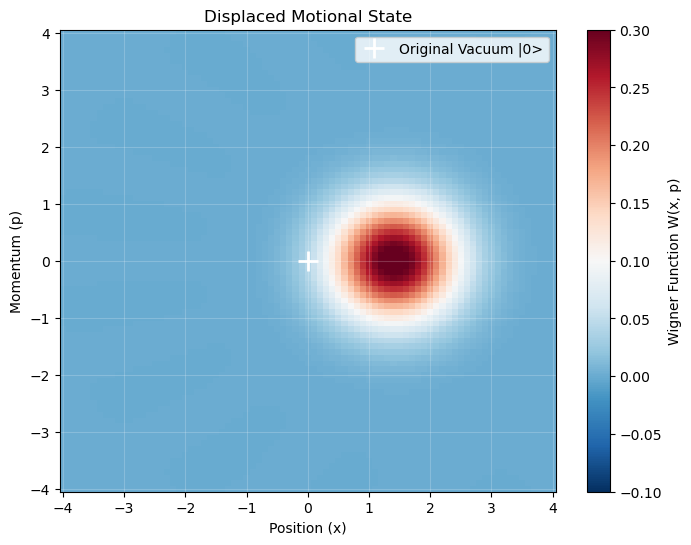

In [22]:
final_state = SDF_apply_with_alpha(0, 1, false, nothing)

println(final_state)
plot_wigner(final_state)



In [8]:
# 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = 0.716 * im 

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

 ψ_ion = normalize(ion["g"] -  ion["e"])

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = identityoperator(ψ_ion.basis) ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * ψ_initial

println(displaced_final_state)

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
     0.54722151763696 + 0.0im
    -0.54722151763696 + 0.0im
                  0.0 + 0.39181060662806294im
                  0.0 - 0.39181060662806294im
 -0.19836918681147203 + 0.0im
  0.19836918681147203 + 0.0im
                  0.0 - 0.08200240843749869im
                  0.0 + 0.08200240843749869im
  0.02935686222252916 + 0.0im
 -0.02935686222252916 + 0.0im
                  0.0 + 0.0094002121203422im
                  0.0 - 0.0094002121203422im
 -0.00274773650091092 + 0.0im
  0.00274773650091092 + 0.0im
                  0.0 - 0.00074359780052438im
                  0.0 + 0.00074359780052438im
  0.00018824989148011 + 0.0im
 -0.00018824989148011 + 0.0im
                  0.0 + 4.484896272068e-5im
                  0.0 - 4.484896272068e-5im
   -1.061027626674e-5 + 0.0im
    1.061027626674e-5 + 0.0im


In [45]:
function SDF_apply_with_alpha(angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        # println("Preparing cat state superposi/tion...")
        red_angle = -angle
        blue_angle = angle
    end
    
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e4 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

    # ---------------------------------------------------------
    # NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    c = 2.99792458e8           

    # 1. Calculate Lamb-Dicke Parameter (η) dynamically
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    # 2. Hijack IonSim's internal matrix element calculator
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Feed the dummy laser into the exact internal physics engine
    # (Note: Unexported internal functions need the module prefix 'IonSim.')
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    # 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    # ---------------------------------------------------------

    # Now build the actual lasers and final chamber
    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    # println(mode)

    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, fock_state_n)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    
    # Ensure our solver array steps exactly up to our calculated target time
    tspan_array = collect(0:0.5:target_time_us)
    if tspan_array[end] < target_time_us
        push!(tspan_array, target_time_us)
    end

    tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

    final_state = sol[end]
    
    return final_state
end

SDF_apply_with_alpha (generic function with 6 methods)

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
  0.43111289877874337 + 2.18469380732e-6im
   -0.427647362589656 - 2.55453038901e-6im
   -1.615101999793e-5 + 0.4308800578530104im
    1.679435547909e-5 - 0.427425679276664im
  -0.3041374776794986 - 2.17331456665e-5im
   0.3017057515457723 + 2.237575940737e-5im
    1.873019819735e-5 - 0.17506613369128643im
   -1.920585875263e-5 + 0.17366908644718534im
  0.08716156874251516 + 1.255787839034e-5im
 -0.08646841784177287 - 1.284602577211e-5im
    -7.08324361751e-6 + 0.03876674743615408im
     7.23363968546e-6 - 0.0384588119401537im
 -0.01572031166529866 - 3.50414522562e-6im
  0.01559597059500932 + 3.57390891353e-6im
     1.56007037403e-6 - 0.00589441439541435im
    -1.58943535426e-6 + 0.00584780982783528im
    0.002066031203257 + 6.3535271978e-7im
   -0.002049778210635 - 6.4672081425e-7im
     -2.4315547894e-7 + 0.00067630531748294im
      2.4729655469e-7 - 0.00067098301050064im
 -0

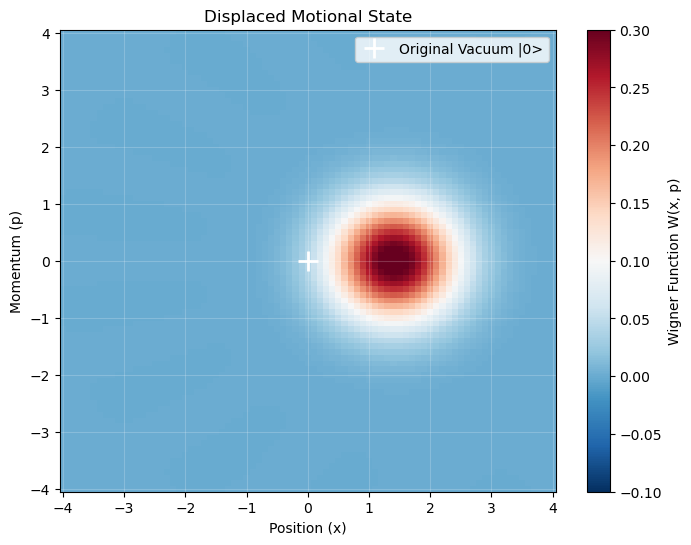

In [39]:
final_state = SDF_apply_with_alpha(0, 1, false, nothing, 0)

println(final_state)
plot_wigner(final_state)



Preparing cat state superposition...
VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
 -0.07681684821344216 + 0.00128721535062743im
 -0.36104400093119954 + 0.00191149537120874im
  -0.0028086972723921 - 0.43698232379534974im
 -0.00250681500624975 - 0.2851347767853369im
   0.5100114622203684 - 0.00213055596717775im
 -0.10597715862563342 - 0.00081749338304019im
  0.00014340548944082 + 0.23343737632723544im
 -0.00109364244168767 - 0.35404498655974787im
  0.05934555594736662 - 0.00109520667191896im
   0.2926640661616205 - 0.00154078208709348im
  0.00104075566486491 + 0.15631375522410976im
  0.00087194279811496 + 0.10413052394480994im
 -0.10570674517230462 + 0.00044561989469418im
  0.02092860301079884 + 0.00014594832692802im
   -1.411249240351e-5 - 0.03190448350856692im
  0.00015523871135909 + 0.04735856547034598im
 -0.00546175673206506 + 0.00010933356323755im
 -0.02778062054207132 + 0.00014571992062099im
   -7.713792226997e-5 - 0.

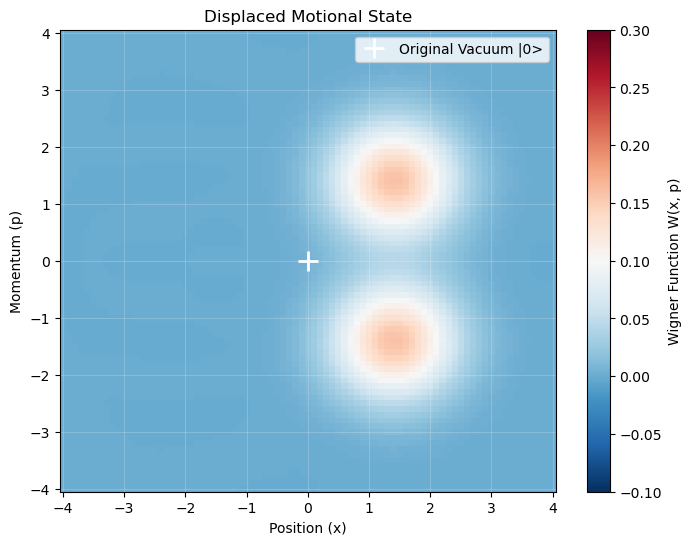

In [40]:
final_state_dis = SDF_apply_with_alpha(pi/2, 1, true, final_state, 0)

println(final_state_dis)
plot_wigner(final_state_dis)


In [55]:
function protocol(initialstate = nothing, beta = 1, alpha = 0.5)

    beta_state = SDF_apply_with_alpha(0, beta, false, initialstate, 0)
    final_state = SDF_apply_with_alpha(pi/2, alpha, true, beta_state, 0)

    return final_state
end

protocol (generic function with 4 methods)

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
Preparing cat state superposition...
VibrationalMode(ν=1.9e6, axis=ẑ, N=10)


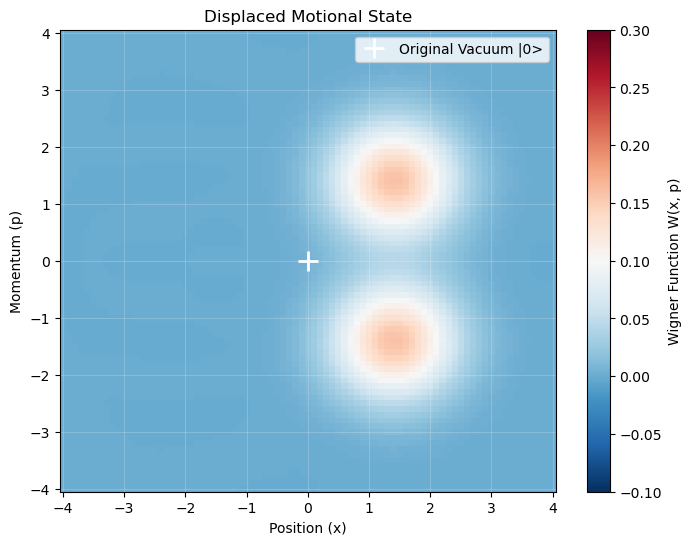

In [42]:
state =protocol(1 , 1)

plot_wigner(state)

In [43]:
using LinearAlgebra

In [44]:
function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Extract dense data
    rho_dense_data = dense(rho1).data
    rho_pert_dense_data = dense(rho2).data

    # 3. Finite difference derivative
    drho_data = (rho_pert_dense_data - rho_dense_data) / d_alpha
    
    # 4. Use Hermitian() to guarantee real eigenvalues and speed up diagonalization
    λ, V = LinearAlgebra.eigen(Hermitian(rho_dense_data))
    
    qfi = 0.0
    n = length(λ)
    
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # 5. Use @views to prevent memory allocation during column slicing
                @views v_i = V[:, i]
                @views v_j = V[:, j]
                
                drho_ij = dot(v_i, drho_data * v_j)
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    return qfi, qcrb
end


calculate_qcrb (generic function with 1 method)

Simulating Fock State |0⟩ (Ancilla Readout)...
Simulating Fock State |1⟩ (Ancilla Readout)...
Simulating Fock State |2⟩ (Ancilla Readout)...
Simulating Fock State |3⟩ (Ancilla Readout)...
Simulating Fock State |4⟩ (Ancilla Readout)...
Simulating Fock State |5⟩ (Ancilla Readout)...


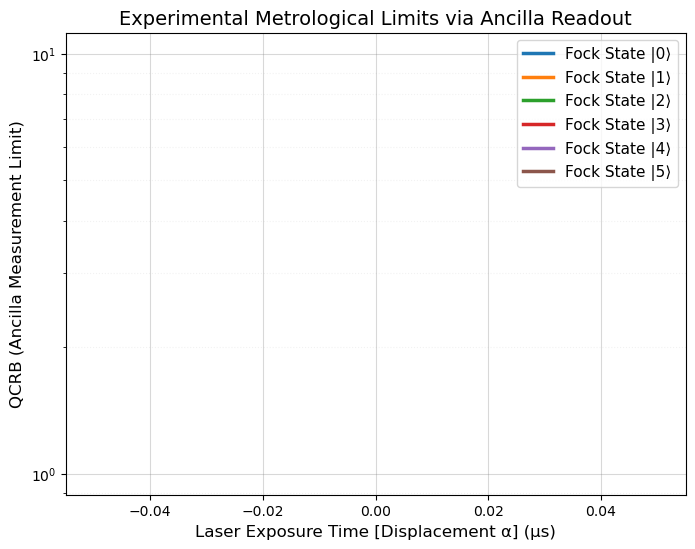

In [46]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 50.0
time_steps = 0.1:1.0:t_max 
states = 0:5 
ψ_ion = normalize(ion["g"] - ion["e"])
# Infinitesimal mathematical signal
d_alpha = 1e-6 

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal


for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(t/50, 1)
        ancilla_base = ptrace(sol1, 2) 

        finalstate = sol1
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(t/50, 1)
        ancilla_perturbed = ptrace(sol2, 2)

        finalstate_perturbed = sol2

        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
    end

    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

PyPlot.yscale("log")
# We can now confidently constrain the Y-axis to relevant physical limits

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Experimental Metrological Limits via Ancilla Readout", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Simulating Fock State |0⟩ (Ancilla Readout)...
Time: 0.1 μs, Fock |0⟩, QCRB: 2.132375530532712e7
Time: 1.1 μs, Fock |0⟩, QCRB: 3.134035382187649e6
Time: 2.1 μs, Fock |0⟩, QCRB: 1282.9443696751891
Time: 3.1 μs, Fock |0⟩, QCRB: 401.3333048157538
Time: 4.1 μs, Fock |0⟩, QCRB: 132.5841571776652
Simulating Fock State |1⟩ (Ancilla Readout)...
Time: 0.1 μs, Fock |1⟩, QCRB: 2.3468467265199367e7
Time: 1.1 μs, Fock |1⟩, QCRB: 112812.47146254974
Time: 2.1 μs, Fock |1⟩, QCRB: 96.69416693432815
Time: 3.1 μs, Fock |1⟩, QCRB: 85.45347552382978
Time: 4.1 μs, Fock |1⟩, QCRB: 25.537297406500695
Simulating Fock State |2⟩ (Ancilla Readout)...
Time: 0.1 μs, Fock |2⟩, QCRB: 7.187465640301784e6
Time: 1.1 μs, Fock |2⟩, QCRB: 1880.8395487117923
Time: 2.1 μs, Fock |2⟩, QCRB: 31.395656998063846
Time: 3.1 μs, Fock |2⟩, QCRB: 249.80726241372662
Time: 4.1 μs, Fock |2⟩, QCRB: 47.05212926037464
Simulating Fock State |3⟩ (Ancilla Readout)...
Time: 0.1 μs, Fock |3⟩, QCRB: 5.7511088320542276e7
Time: 1.1 μs, Fock |3⟩, QC

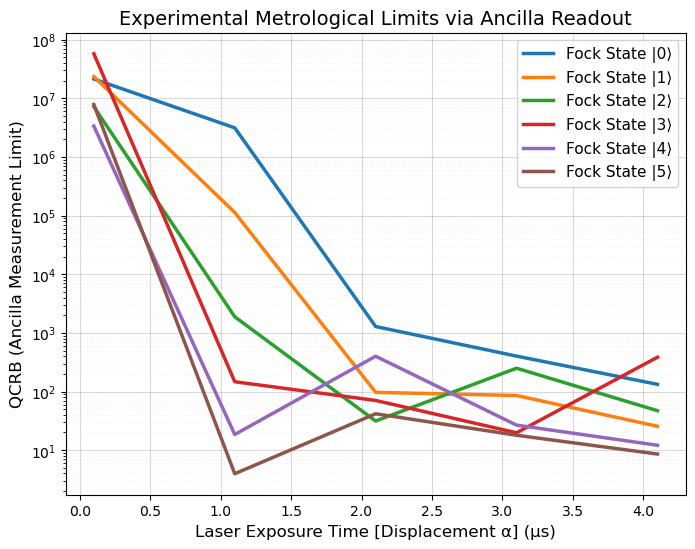

In [56]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 5.0
time_steps = 0.1:1.0:t_max 
states = 0:5 
ψ_ion = normalize(ion["g"] - ion["e"])
# Infinitesimal mathematical signal
d_alpha = 0.1

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal


for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, t, 1)
        ancilla_base = ptrace(sol1, 2) 

        finalstate = sol1
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, t, 1)
        ancilla_perturbed = ptrace(sol2, 2)

        finalstate_perturbed = sol2

        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Time: ", round(t, digits=2), " μs, Fock |", n, "⟩, QCRB: ", qcrb)
    end

    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

PyPlot.yscale("log")
# We can now confidently constrain the Y-axis to relevant physical limits

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Experimental Metrological Limits via Ancilla Readout", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

In [52]:
 sol1 = protocol(1, 1)
ancilla_base = ptrace(sol1, 2)

Operator(dim=2x2)
  basis: ⁴⁰Ca
  0.551813+0.0im          0.0458079+0.000232091im
 0.0458079-0.000232091im   0.448254+0.0im

In [53]:
sol2 = protocol(1.1, 1)
        ancilla_perturbed = ptrace(sol2, 2)


Operator(dim=2x2)
  basis: ⁴⁰Ca
   0.56604+0.0im          0.0214399+0.000366834im
 0.0214399-0.000366834im   0.434033+0.0im

In [54]:
qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)

println("QFI: ", qfi)
println("QCRB: ", qcrb)

QFI: 0.3186739502398302
QCRB: 3.1380035903386894


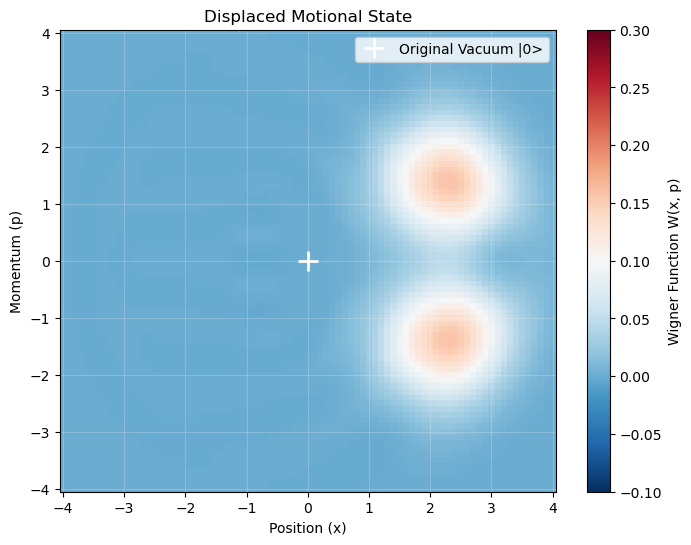

In [74]:
sol = protocol(nothing, 1.6, 1)
plot_wigner(sol) 

Simulating Fock State |0⟩ (Ancilla Readout)...
Beta: 0.01 μs, Fock |0⟩, QCRB: 3.109688339533595e8
Beta: 0.06 μs, Fock |0⟩, QCRB: 7.977714095119542e7
Beta: 0.11 μs, Fock |0⟩, QCRB: 5.012178931385119e7
Beta: 0.16 μs, Fock |0⟩, QCRB: 3.4868784056810446e7
Beta: 0.21 μs, Fock |0⟩, QCRB: 2.8840290527477723e7
Beta: 0.26 μs, Fock |0⟩, QCRB: 3.1760376105227742e7
Beta: 0.31 μs, Fock |0⟩, QCRB: 1.367013420201798e8
Beta: 0.36 μs, Fock |0⟩, QCRB: 7.649916571279874e7
Beta: 0.41 μs, Fock |0⟩, QCRB: 1.5188512487988698e8
Beta: 0.46 μs, Fock |0⟩, QCRB: 2.5993576544739935e8
Beta: 0.51 μs, Fock |0⟩, QCRB: 5.554787397292984e8
Beta: 0.56 μs, Fock |0⟩, QCRB: 4.5311829107935923e8
Beta: 0.61 μs, Fock |0⟩, QCRB: 3.398638271514782e8
Beta: 0.66 μs, Fock |0⟩, QCRB: 3.595928489012605e8
Beta: 0.71 μs, Fock |0⟩, QCRB: 2.5766323598399836e8
Beta: 0.76 μs, Fock |0⟩, QCRB: 6.725776995455725e7
Beta: 0.81 μs, Fock |0⟩, QCRB: 8.886453037876417e7
Beta: 0.86 μs, Fock |0⟩, QCRB: 1.0750307464541776e8
Beta: 0.91 μs, Fock |0⟩, QC

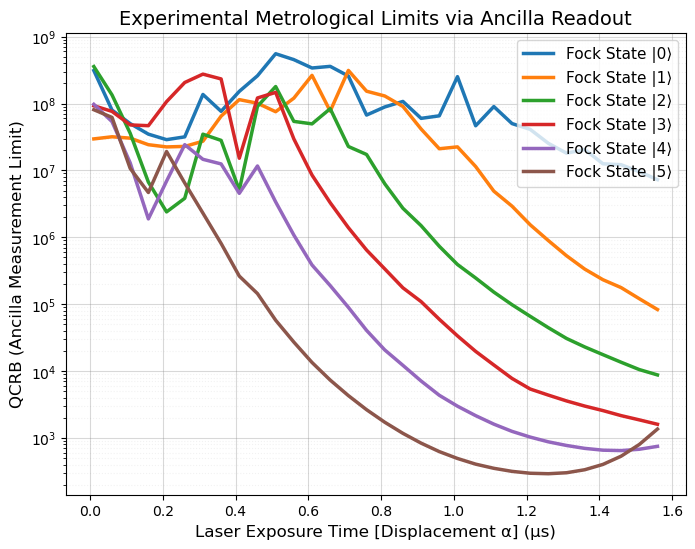

In [75]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 0:5 
ψ_ion = normalize(ion["g"] - ion["e"])
# Infinitesimal mathematical signal
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal


for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, t, 1)
        ancilla_base = ptrace(sol1, 2) 

        finalstate = sol1
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, t, 1)
        ancilla_perturbed = ptrace(sol2, 2)

        finalstate_perturbed = sol2

        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, Fock |", n, "⟩, QCRB: ", qcrb)
    end

    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

PyPlot.yscale("log")
# We can now confidently constrain the Y-axis to relevant physical limits

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Experimental Metrological Limits via Ancilla Readout", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)